In [24]:
import pypowsybl.network as pn
import pypowsybl.dynamic as dyn
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

In [25]:
from helpers import *

In [26]:
network = pn.load('nordic32.xiidm')
generators = network.get_generators(all_attributes=True)
voltage_levels = network.get_voltage_levels(all_attributes=True)

In [27]:
model_mapping = dyn.ModelMapping()

for generatorId, generatorProperties in generators.iterrows():
    energy_source_value = generatorProperties['energy_source']
    if energy_source_value == "HYDRO":
        model_mapping.add_synchronous_generator(static_id=generatorId, parameter_set_id=generatorId, model_name='GeneratorSynchronousThreeWindingsGoverNordicVRNordic')
    elif energy_source_value == "THERMAL":
        model_mapping.add_synchronous_generator(static_id=generatorId, parameter_set_id=generatorId, model_name='GeneratorSynchronousFourWindingsPmConstVRNordic')
    elif energy_source_value == "OTHER":
        model_mapping.add_synchronous_generator(static_id=generatorId, parameter_set_id=generatorId, model_name='GeneratorSynchronousThreeWindingsPmConstVRNordic')

In [28]:
event_mapping = dyn.EventMapping()
event_mapping.add_node_fault(static_id='4032_401', start_time=1, fault_time=0.1, r_pu=0.025, x_pu=0.025)
event_mapping.add_disconnection(static_id='L4032-4044', start_time=1.1)

In [29]:
variables_mapping = dyn.OutputVariableMapping()
variables_mapping.add_standard_model_curves('1042_131', 'U_value')

In [30]:
network = pn.load('nordic32.xiidm')
sim = dyn.Simulation()
res = sim.run(network, model_mapping, event_mapping, variables_mapping, 0, 175)

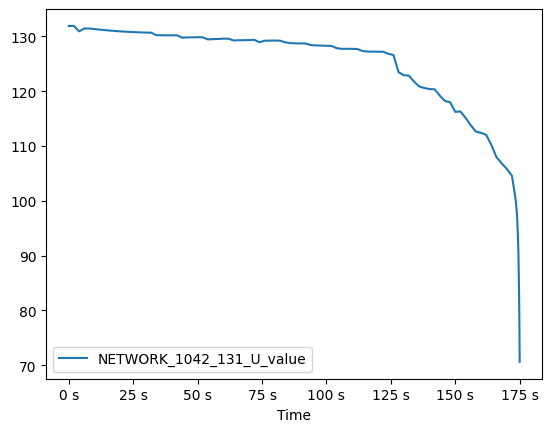

In [31]:
plot(res.curves())

In [32]:
tfo_ids = ['Tr11-1011', 'Tr12-1012', 'Tr13-1013', 'Tr22-1022', 'Tr1-1041', 'Tr2-1042', 'Tr3-1043', 'Tr4-1044', 'Tr5-1045', 'Tr31-2031',
               'Tr32-2032', 'Tr41-4041', 'Tr42-4042', 'Tr43-4043', 'Tr46-4046', 'Tr47-4047', 'Tr51-4051', 'Tr61-4061', 'Tr62-4062', 'Tr63-4063'
               'Tr71-4071', 'Tr72-4072']
measurement_id = '1042_131'
add_tap_changer_blocking(model_mapping, 'TCB', tfo_ids, measurement_id)

In [33]:
network = pn.load('nordic32.xiidm')
res2 = sim.run(network, model_mapping, event_mapping, variables_mapping, 0, 300)

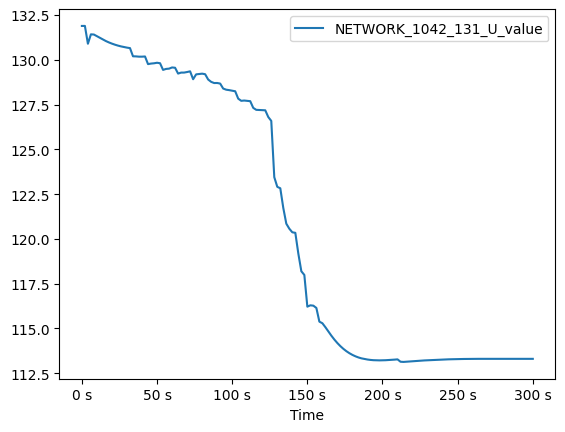

In [34]:
plot(res2.curves())

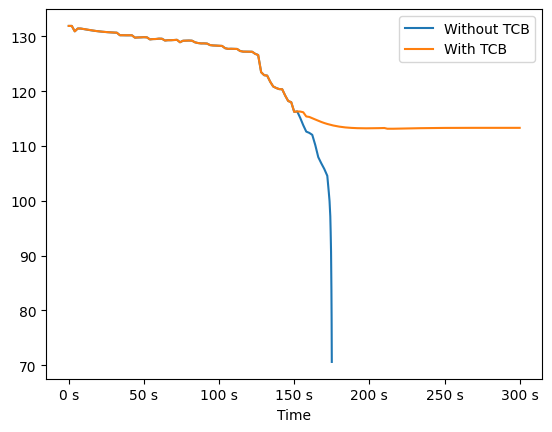

In [35]:
curves1 = res.curves()
curveName = curves1.columns.tolist()[0]
figure = addPlot(res.curves(), curveName, 'Without TCB')
plotSameGraph(res2.curves(), figure, curveName, 'With TCB')